In [19]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, 'code')
from shared import load_condition, glauber_constants, mse
from observable_variants import start_from_m, start_from_eps, start_from_eps2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
})

device: cpu


In [20]:
data = load_condition()
t_grid   = data['t_grid']
m_bar    = data['m_bar']
eps_bar  = data['eps_bar']
eps2_bar = data['eps2_bar']
a0_true, a1_true, a2_true = glauber_constants(
    data['beta_true'], data['h_true'], data['J_true']
)
print(f'Condition: β={data["beta_true"]:+.3f}  h={data["h_true"]:+.3f}  J={data["J_true"]:+.3f}')
print(f'Analytical (a₀, a₁, a₂) = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')

Condition: β=+0.900  h=+0.058  J=+1.167
Analytical (a₀, a₁, a₂) = (+0.0547, +0.9703, -0.0487)


In [21]:
results = {}
for fn, key in [
    (start_from_m,    'from_m'),
    (start_from_eps,  'from_eps'),
    (start_from_eps2, 'from_eps2'),
]:
    print(f'\n {fn.__name__} ')
    r = fn(data, device=device)
    r['mse_m']    = mse(r['m_hat'],    m_bar)
    r['mse_eps']  = mse(r['eps_hat'],  eps_bar)
    r['mse_eps2'] = mse(r['eps2_hat'], eps2_bar)
    r['da_mean']  = (abs(r['a0'] - a0_true) + abs(r['a1'] - a1_true) + abs(r['a2'] - a2_true)) / 3.0
    results[key] = r
    print(f'  MSE m = {r["mse_m"]:.2e}    MSE ε = {r["mse_eps"]:.2e}    MSE ε₂ = {r["mse_eps2"]:.2e}')
    print(f'  recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f})')
    print(f'  mean |Δa| = {r["da_mean"]:.3e}    {r["n_params"]:,} params    {r["time_sec"]:.1f} s')


 start_from_m 
  MSE m = 4.51e-06    MSE ε = 2.89e-05    MSE ε₂ = 8.88e-05
  recovered (a₀, a₁, a₂) = (+0.0989, +0.6086, +1.4744)
  mean |Δa| = 6.430e-01    12,676 params    10.5 s

 start_from_eps 
  MSE m = 3.62e-05    MSE ε = 4.36e-05    MSE ε₂ = 0.00e+00
  recovered (a₀, a₁, a₂) = (+0.7365, -0.0698, +0.2091)
  mean |Δa| = 6.599e-01    12,676 params    11.7 s

 start_from_eps2 
  MSE m = 0.00e+00    MSE ε = 2.74e-05    MSE ε₂ = 4.41e-07
  recovered (a₀, a₁, a₂) = (+0.0455, +0.8934, +0.5004)
  mean |Δa| = 2.118e-01    12,673 params    3.3 s


In [22]:
header = (f'{"variant":<58s}  {"MSE m":>9s}  {"MSE ε":>9s}  {"MSE ε₂":>9s}  '
          f'{"Δa mean":>11s}  {"native ODE":>10s}')
for key in ['from_m', 'from_eps', 'from_eps2']:
    r = results[key]
    native = 'yes' if r['physics_native'] else 'no'
    print(f'{r["name"]:<58s}  '
          f'{r["mse_m"]:>9.2e}  {r["mse_eps"]:>9.2e}  {r["mse_eps2"]:>9.2e}  '
          f'{r["da_mean"]:>11.3e}  {native:>10s}')

Start from m   (m-equation, native ODE)                      4.51e-06   2.89e-05   8.88e-05    6.430e-01         yes
Start from ε   (ε-equation, observed m and ε₂ as forcing)    3.62e-05   4.36e-05   0.00e+00    6.599e-01         yes
Start from ε₂  (no native ODE → curve-fit + post-hoc lstsq)   0.00e+00   2.74e-05   4.41e-07    2.118e-01          no


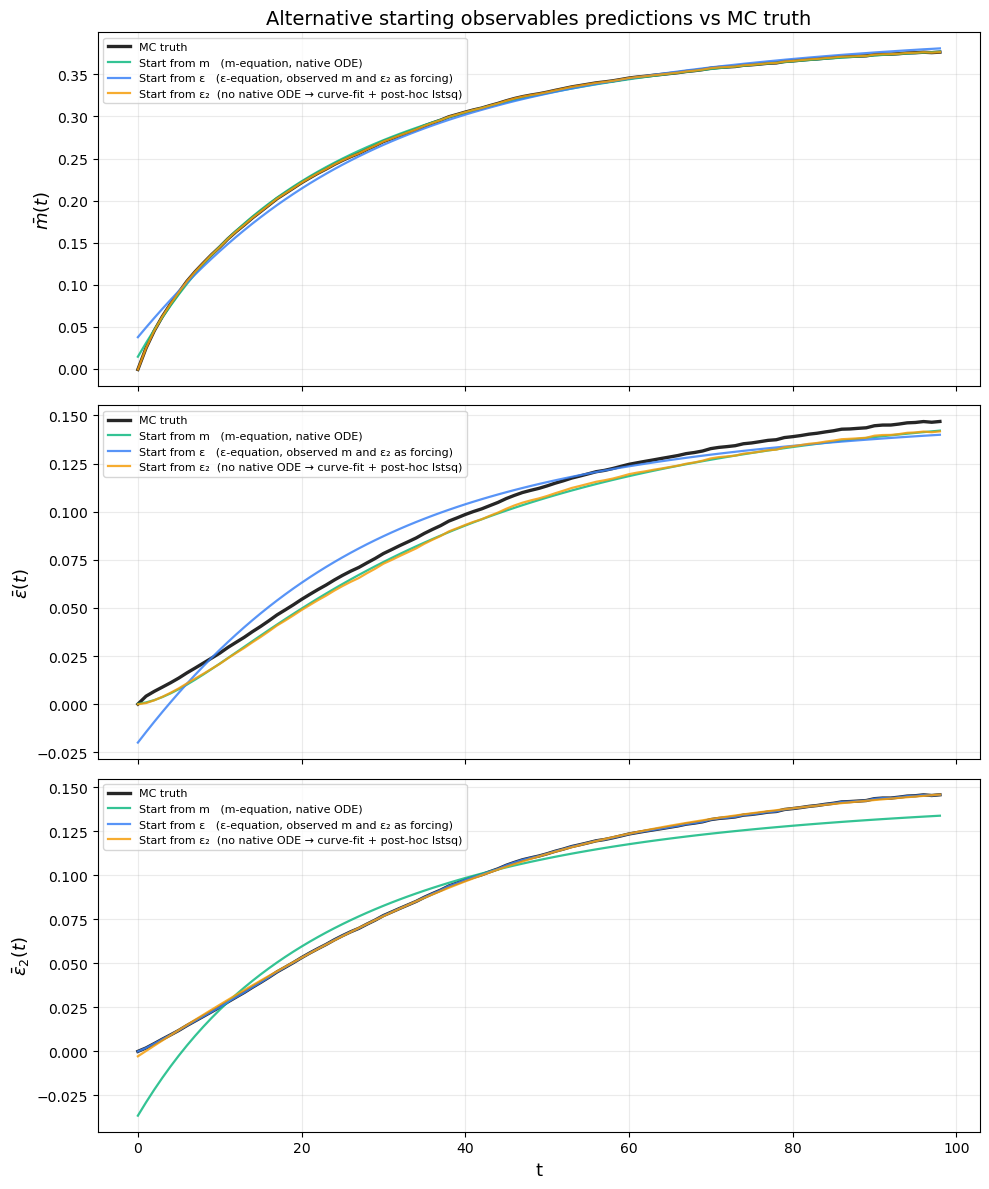

In [23]:
colors = {'from_m': '#10b981', 'from_eps': '#3b82f6', 'from_eps2': '#f59e0b'}

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for ax, (truth, key_obs, lbl) in zip(axes, [
    (m_bar, 'm_hat', r'$\bar m(t)$'),
    (eps_bar, 'eps_hat', r'$\bar\varepsilon(t)$'),
    (eps2_bar, 'eps2_hat', r'$\bar\varepsilon_2(t)$'),
]):
    ax.plot(t_grid, truth, 'k-', lw=2.4, alpha=0.85, label='MC truth')
    for key, r in results.items():
        ax.plot(t_grid, r[key_obs], color=colors[key], lw=1.6, alpha=0.85, label=r['name'])
    ax.set_ylabel(lbl); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t')
axes[0].set_title('Alternative starting observables predictions vs MC truth')
plt.tight_layout(); plt.show()

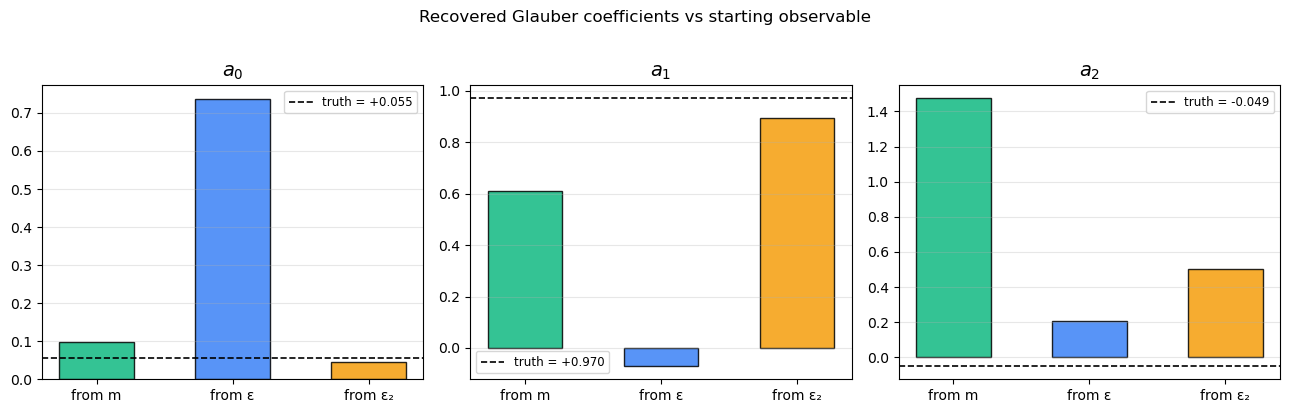

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (lbl, key_a, true_val) in zip(axes, [
    (r'$a_0$', 'a0', a0_true),
    (r'$a_1$', 'a1', a1_true),
    (r'$a_2$', 'a2', a2_true),
]):
    names = [results[k]['name'].split(' ')[1] for k in results]
    values = [results[k][key_a] for k in results]
    bar_colors = [colors[k] for k in results]
    xs = np.arange(len(values))
    ax.bar(xs, values, 0.55, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(true_val, color='k', ls='--', lw=1.2, label=f'truth = {true_val:+.3f}')
    ax.set_xticks(xs); ax.set_xticklabels(['from m', 'from ε', 'from ε₂'])
    ax.set_title(lbl); ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8.5, loc='best')
plt.suptitle('Recovered Glauber coefficients vs starting observable', y=1.02)
plt.tight_layout(); plt.show()